**<center><font size=5>Using Transfer Learning to improve the classifier</font></center>**

---

**Table of Contents**

- <a href='#intro'>1. Project Overview and Objectives</a>
  - <a href='#dataset'>1.1. Data Set Description</a>
  - <a href='#Plants'>1.2. What is Plant Village - or Plant disease?</a>
  - <a href='#Plants'>1.3. What is Transfer Learning ?</a>
- <a href='#env'>2. Setting up the Environment</a>
- <a href='#Opt'>3. Load & Optimize Dataset Pipeline</a>
- <a href='#Pre'>4. Load Pretrained Model - The ResNet50 revolution</a>
- <a href='#Frz'>5. Freeze the Base Model</a>
- <a href='#Build'>6. Build the Transfer Learning Model</a>
- <a href='#Train'>7. Compile and train the Model</a>
- <a href='#Plots'>8. Plot Training Results </a>
- <a href='#Fine'>9. What if we use Fine-tunning ? </a>
  - <a href='#Finet'>9.1. What is Fine-tunning</a>
  - <a href='#Finet2'>9.2 Fine-tunned model </a>

---


# <a href='#intro'>1. Project Overview and Objectives</a>


# 🌿 Plant Disease Detection using Deep Learning

The goal of this project is to build a deep learning model capable of **detecting plant diseases from leaf images**. Plant diseases represent a major challenge in agriculture because they can significantly reduce crop yield and affect food production worldwide.

By leveraging **Computer Vision** and **Convolutional Neural Networks (CNNs)**, we aim to automatically classify plant leaf images into their corresponding disease categories. This approach can help farmers and agricultural systems detect diseases earlier and take appropriate actions.

In this project, we explore two different deep learning strategies:

- 🔨 Building a **CNN model from scratch**
- 🔁 Using **Transfer Learning** with a pretrained deep neural network

The objective is not only to build a high-performance model but also to understand the theoretical and practical aspects of modern deep learning pipelines used in computer vision systems.


## <a href='#dataset'>1.1. Data Set Description</a>


For this project we use the **PlantVillage Dataset**, one of the most widely used datasets for plant disease recognition in machine learning.

### Key characteristics of the dataset

| Property       | Details                                       |
| -------------- | --------------------------------------------- |
| **Images**     | RGB images of plant leaves                    |
| **Image size** | Rescaled to 224 × 224 pixels                  |
| **Classes**    | Multiple plant species and disease categories |
| **Content**    | Healthy leaves and diseased leaves            |

Each image represents a leaf from a specific plant, labeled with the disease affecting it or marked as healthy.

Examples of diseases present in the dataset include:

- 🍂 Early blight
- 🍃 Leaf mold
- 🦠 Bacterial spot
- 🌫️ Powdery mildew
- ✅ Healthy leaves

This dataset allows us to train models capable of learning visual patterns associated with plant diseases, such as **color changes**, **spots**, **texture irregularities**, or **deformations** on the leaf surface.


## <a href='#Plants'>1.2. What is Plant Village - or Plant disease?</a>


**PlantVillage** is an open research initiative focused on using technology to improve agricultural systems and help farmers detect plant diseases more efficiently.

The PlantVillage dataset was created by researchers to provide a large collection of labeled plant leaf images. It has become a **benchmark dataset** for computer vision models in agriculture.

The dataset enables researchers and engineers to develop **AI-powered diagnostic systems** that can automatically detect plant diseases using image recognition.

Such systems could eventually be deployed in:

- 📱 Mobile applications for farmers
- 🌾 Agricultural monitoring systems
- 🤖 Smart farming platforms
- 🔍 Automated crop inspection tools


## <a href='#Plants'>1.3. What is Transfer Learning ?</a>


Training a deep neural network from scratch typically requires very large datasets and extensive computational resources.

**Transfer Learning** is a technique that allows us to reuse knowledge learned from large datasets to solve new problems more efficiently.

Instead of training a model from scratch, we start with a **pretrained model** that has already learned rich visual representations from a massive dataset such as **ImageNet**.

The idea is that the model has already learned to recognize:

- 📐 Edges
- 🔷 Shapes
- 🧱 Textures
- 🎨 Complex visual patterns

These learned features can then be **adapted to a new task**, such as plant disease classification.

Transfer learning offers several advantages:

| Advantage                 | Description                           |
| ------------------------- | ------------------------------------- |
| ⚡ **Faster training**    | Fewer epochs needed to converge       |
| 📊 **Better performance** | Higher accuracy with smaller datasets |
| 💰 **Reduced cost**       | Less computational resources required |


# <a href='#env'>2. Setting up the Environment</a>


In [ ]:
import tensorflow as tf

print("Num GPUs Available:", len(tf.config.list_physical_devices("GPU")))
print(tf.config.list_physical_devices("GPU"))

Num GPUs Available: 1
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

import matplotlib.pyplot as plt

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    try:
        tf.config.set_visible_devices(gpus[0], "GPU")
        tf.config.experimental.set_memory_growth(gpus[0], True)
        print("GPU activated")
    except RuntimeError as e:
        print(e)

GPU activated


In [23]:
temp_ds = tf.keras.utils.image_dataset_from_directory("Dataset/PlantVillage")
print(temp_ds.class_names)

Found 20638 files belonging to 15 classes.
['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


# <a href='#Opt'>3. Load & Optimize Dataset Pipeline</a>


In [ ]:
dataset_path = "Dataset/PlantVillage"

train_ds = keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224, 224),  # ✅ ResNet expects 224x224
    batch_size=32,
)

val_ds = keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224, 224),  # ✅ ResNet expects 224x224
    batch_size=32,
)

print("Train batches:", len(train_ds))
print("Validation batches:", len(val_ds))


class_names = train_ds.class_names

Found 20638 files belonging to 15 classes.
Using 16511 files for training.
Found 20638 files belonging to 15 classes.
Using 4127 files for validation.
Train batches: 516
Validation batches: 129


## ⚠️ Dataset Issue

During the experiment we discovered an issue with the dataset structure.  
The dataset contained **an extra folder that was mistakenly interpreted as a class**.

### Problem

The raw class list looked like this:

['Pepper**bell\_**Bacterial_spot',
'Pepper**bell\_**healthy',

'PlantVillage', ❗ error → should be removed

'Potato***Early_blight',
'Potato***Late_blight',
'Potato\_\_\_healthy',
'Tomato_Bacterial_spot',
...
]

> 🗑️ **`PlantVillage` is not a class** — it is the **root folder of the dataset** that was accidentally included in the class list.

This caused the model to incorrectly treat it as an additional category, which can significantly affect the training and validation results.

### Solution

The incorrect folder was **manually removed from the dataset directory**.

After cleaning the dataset, the expected folder structure should look like this:

> **Note:** The effect of this cleanup can be observed in the **Fine-Tuning section**, where the model performance improves after fixing the dataset structure.


In [9]:
class_names = train_ds.class_names
num_classes = len(class_names)

print(class_names)

['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


When training deep learning models, efficient data loading is critical for performance.

TensorFlow provides a powerful dataset API that allows us to optimize how data is fed to the GPU.


In [10]:
train_ds = train_ds.shuffle(1000)

In [11]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

`tf.data.AUTOTUNE` automatically determines the **optimal number of elements** to process in parallel based on the available system resources.

The function `prefetch()` allows the dataset to **prepare the next batch** of data while the model is training on the current batch.

### Without prefetching ❌

The training pipeline would look like this:

```
Load Batch → Train Model → Load Next Batch → Train Model → ...
```

### With prefetching ✅

TensorFlow **overlaps** these operations:

```
Train Model
           ↕  (simultaneously)
Load Next Batch
```

This significantly **reduces idle time** for the GPU and improves overall training performance.


# <a href='#Pre'>4. Load Pretrained Model - The ResNet50 revolution</a>


In this project we use ResNet50, a 50-layer deep convolutional neural network.


In [13]:
base_model = keras.applications.ResNet50(
    weights="imagenet", include_top=False, input_shape=(224, 224, 3)
)

## ResNet — Residual Networks

Deep neural networks became increasingly powerful as researchers added more layers to their architectures.

However, increasing network depth introduced a major problem known as the **vanishing gradient problem**, where deeper networks became harder to train and sometimes performed **worse** than shallower ones.

This challenge was addressed by the introduction of **Residual Networks (ResNet)**.

---

### 🔑 Key Idea — Skip Connections

ResNet introduced **skip connections** (or residual connections).

Instead of learning a direct mapping:

$$H(x)$$

ResNet learns a **residual function**:

$$F(x) = H(x) - x$$

This allows the network to learn the **difference** between the input and the desired output rather than the full transformation.

The architecture includes **shortcut connections** that bypass certain layers and directly add the input to the output of deeper layers.

---

### 🏆 Impact

| Achievement        | Details                                    |
| ------------------ | ------------------------------------------ |
| **Problem solved** | Vanishing gradient in very deep networks   |
| **Depth enabled**  | 50, 101, or even 152 layers                |
| **Competition**    | Won ImageNet 2015                          |
| **Legacy**         | Revolutionized deep learning architectures |


### Parameter Explanation

| Parameter     | Value           | Description                                                                        |
| ------------- | --------------- | ---------------------------------------------------------------------------------- |
| `weights`     | `"imagenet"`    | Loads pretrained weights from ImageNet — millions of images across 1000 categories |
| `include_top` | `False`         | Removes the final classification layer so we can replace it with our own           |
| `input_shape` | `(224, 224, 3)` | Defines the input image size expected by the model                                 |

The pretrained network acts as a **feature extractor**, meaning it processes the image and produces high-level visual representations that can be used to classify plant diseases.

We then add our own **custom classification layers** on top of the model to adapt it to our dataset.

```
ImageNet Pretrained ResNet
         ↓
  Feature Extraction
         ↓
 Custom Classifier Head
         ↓
 Plant Disease Categories
```


# <a href='#Frz'>5. Freeze the Base Model</a>


In [37]:
base_model.trainable = False

# <a href='#Build'>6. Build the Transfer Learning Model</a>


we aim to:

Build a CNN model capable of detecting plant diseases

Compare training from scratch vs transfer learning

Understand modern deep learning pipelines

Apply computer vision techniques to a real-world agricultural problem

This project represents a practical example of how artificial intelligence can contribute to improving agricultural productivity and food security.


In [ ]:
inputs = keras.Input(shape=(75, 75, 3))

x = keras.applications.resnet.preprocess_input(inputs)

x = base_model(x, training=False)

x = layers.Flatten()(x)

x = layers.Dense(1000, activation="relu")(x)

x = layers.Dropout(0.5)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs)

# <a href='#Train'>7. Compile and train the Model</a>


In [40]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [41]:
history = model.fit(train_ds, validation_data=val_ds, epochs=50)

Epoch 1/50
1032/1032 [==============================] - 35s 31ms/step - loss: 1.4282 - accuracy: 0.4508 - val_loss: 1.0602 - val_accuracy: 0.4591
Epoch 2/50
1032/1032 [==============================] - 32s 31ms/step - loss: 1.0608 - accuracy: 0.4811 - val_loss: 0.9965 - val_accuracy: 0.4434
Epoch 3/50
1032/1032 [==============================] - 32s 31ms/step - loss: 0.9836 - accuracy: 0.4866 - val_loss: 0.9869 - val_accuracy: 0.4105
Epoch 4/50
1032/1032 [==============================] - 32s 31ms/step - loss: 0.9322 - accuracy: 0.4949 - val_loss: 0.9826 - val_accuracy: 0.4177
Epoch 5/50
1032/1032 [==============================] - 41s 39ms/step - loss: 0.9001 - accuracy: 0.5060 - val_loss: 0.9776 - val_accuracy: 0.3912
Epoch 6/50
1032/1032 [==============================] - 40s 39ms/step - loss: 0.8776 - accuracy: 0.5083 - val_loss: 0.9833 - val_accuracy: 0.3853
Epoch 7/50
1032/1032 [==============================] - 43s 41ms/step - loss: 0.8543 - accuracy: 0.5153 - val_loss: 0.9851 -

# <a href='#Plots'>8. Plot Training Results </a>


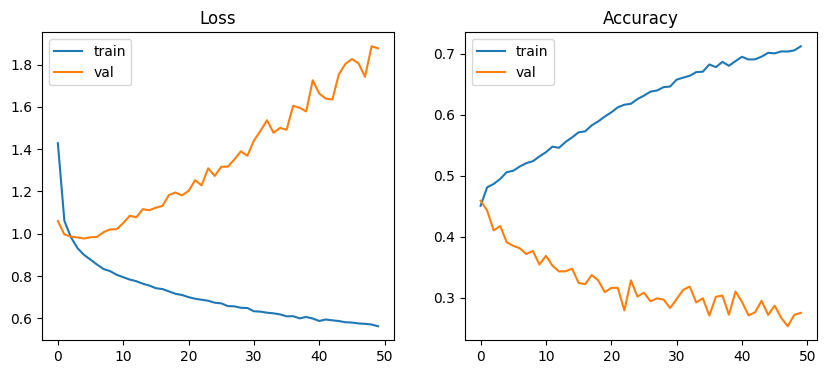

In [42]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy")
plt.legend()

plt.show()

I'll explain what happened here : So These are the plots before changing / updating the dataset : which was containing another nested file (WRONG ONE) that our model took it as a real class :
I kept these plots and results in purpose for you to see how a single simple mistake can lead a really good architecture to a wrong road ! and you'll see that in the second part (Fine-tunned model) I modified the dataset and the plots (results) are just perfect , and you'll notice it by yourselves


# <a href='#Fine'>9. What if we use Fine-tunning ? </a>

## <a href='#Finet'>9.1. What is Fine-tunning</a>

Fine Tuning is the approach in which a pretrained model is used. However, few of the layers are made trainable to understand the patterns in the current dataset. Morevoer, regularization can also be added in the form of dropout layers.

Remember : we can have a robust model but it'll be so dumb in the training (and validation) and it's not because of its architecture , but the real issue is in another side - THE DATA


## <a href='#Finet2'>9.2 Fine-tunned model </a>


In [ ]:
normalization_layer = layers.Rescaling(1.0 / 255)
# 1. On débloque une partie du modèle
base_model.trainable = True
for layer in base_model.layers[:-50]:  # 30 couches c'est souvent le "sweet spot"
    layer.trainable = False

inputs = keras.Input(shape=(224, 224, 3))

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.2),
        layers.RandomZoom(0.2),
    ]
)

x = data_augmentation(inputs)
x = keras.applications.resnet.preprocess_input(x)

# training=False ici est CRUCIAL même si on entraîne.
# Cela garde les stats de BatchNormalization figées (évite l'explosion du gradient)
x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)  # Ajout pour stabiliser le transfert
x = layers.Dropout(0.5)(x)  # Augmenté à 0.5 si vous avez peu de données

x = layers.Dense(256, activation="relu")(x)  # 1000 c'est bcp, 512 suffit souvent
x = layers.Dropout(0.4)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)
model = keras.Model(inputs, outputs)

# 2. LE CHANGEMENT CLÉ : Le Learning Rate
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-6),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [15]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True, verbose=1
)

In [ ]:
# Train with fine-tuning
with tf.device("/GPU:0"):
    history_finetuning = model.fit(
        train_ds, epochs=50, validation_data=val_ds, callbacks=[early_stopping]
    )

Epoch 1/50
516/516 [==============================] - 184s 288ms/step - loss: 4.5971 - accuracy: 0.0752 - val_loss: 2.8648 - val_accuracy: 0.1073
Epoch 2/50
516/516 [==============================] - 157s 280ms/step - loss: 3.8249 - accuracy: 0.1089 - val_loss: 2.4723 - val_accuracy: 0.1972
Epoch 3/50
516/516 [==============================] - 156s 276ms/step - loss: 3.1935 - accuracy: 0.1623 - val_loss: 2.0685 - val_accuracy: 0.2963
Epoch 4/50
516/516 [==============================] - 246s 465ms/step - loss: 2.6883 - accuracy: 0.2340 - val_loss: 1.7455 - val_accuracy: 0.4173
Epoch 5/50
516/516 [==============================] - 167s 299ms/step - loss: 2.3242 - accuracy: 0.3025 - val_loss: 1.4697 - val_accuracy: 0.5384
Epoch 6/50
516/516 [==============================] - 155s 283ms/step - loss: 2.0228 - accuracy: 0.3748 - val_loss: 1.2453 - val_accuracy: 0.6237
Epoch 7/50
516/516 [==============================] - 293s 546ms/step - loss: 1.7823 - accuracy: 0.4389 - val_loss: 1.0937 -

# <a href='#PlotsFinet'>10. The new plots and evaluations </a>


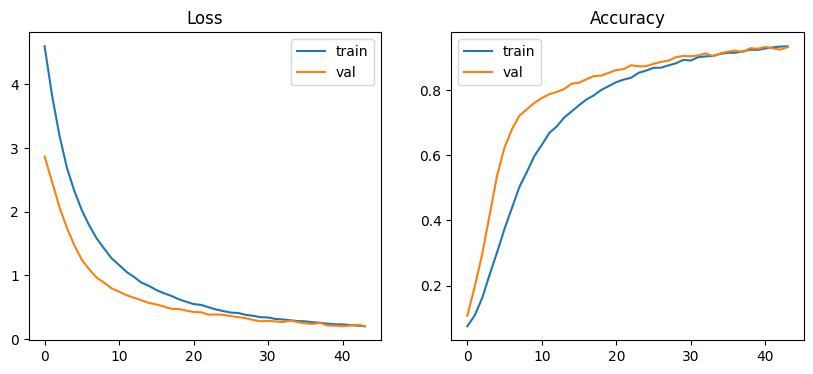

In [17]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history_finetuning.history["loss"], label="train")
plt.plot(history_finetuning.history["val_loss"], label="val")
plt.title("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_finetuning.history["accuracy"], label="train")
plt.plot(history_finetuning.history["val_accuracy"], label="val")
plt.title("Accuracy")
plt.legend()

plt.show()

We can improve more our model , but even like that , we can see that it really improved !


In [18]:
loss, acc = model.evaluate(val_ds)

print("Test Loss:", loss)
print("Test Accuracy:", acc)

129/129 [==============================] - 10s 76ms/step - loss: 0.2014 - accuracy: 0.9324
Test Loss: 0.20141911506652832
Test Accuracy: 0.932396411895752


In [19]:
import numpy as np

y_pred_probs = model.predict(val_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

129/129 [==============================] - 11s 78ms/step


In [20]:
y_true = np.concatenate([y for x, y in val_ds], axis=0)

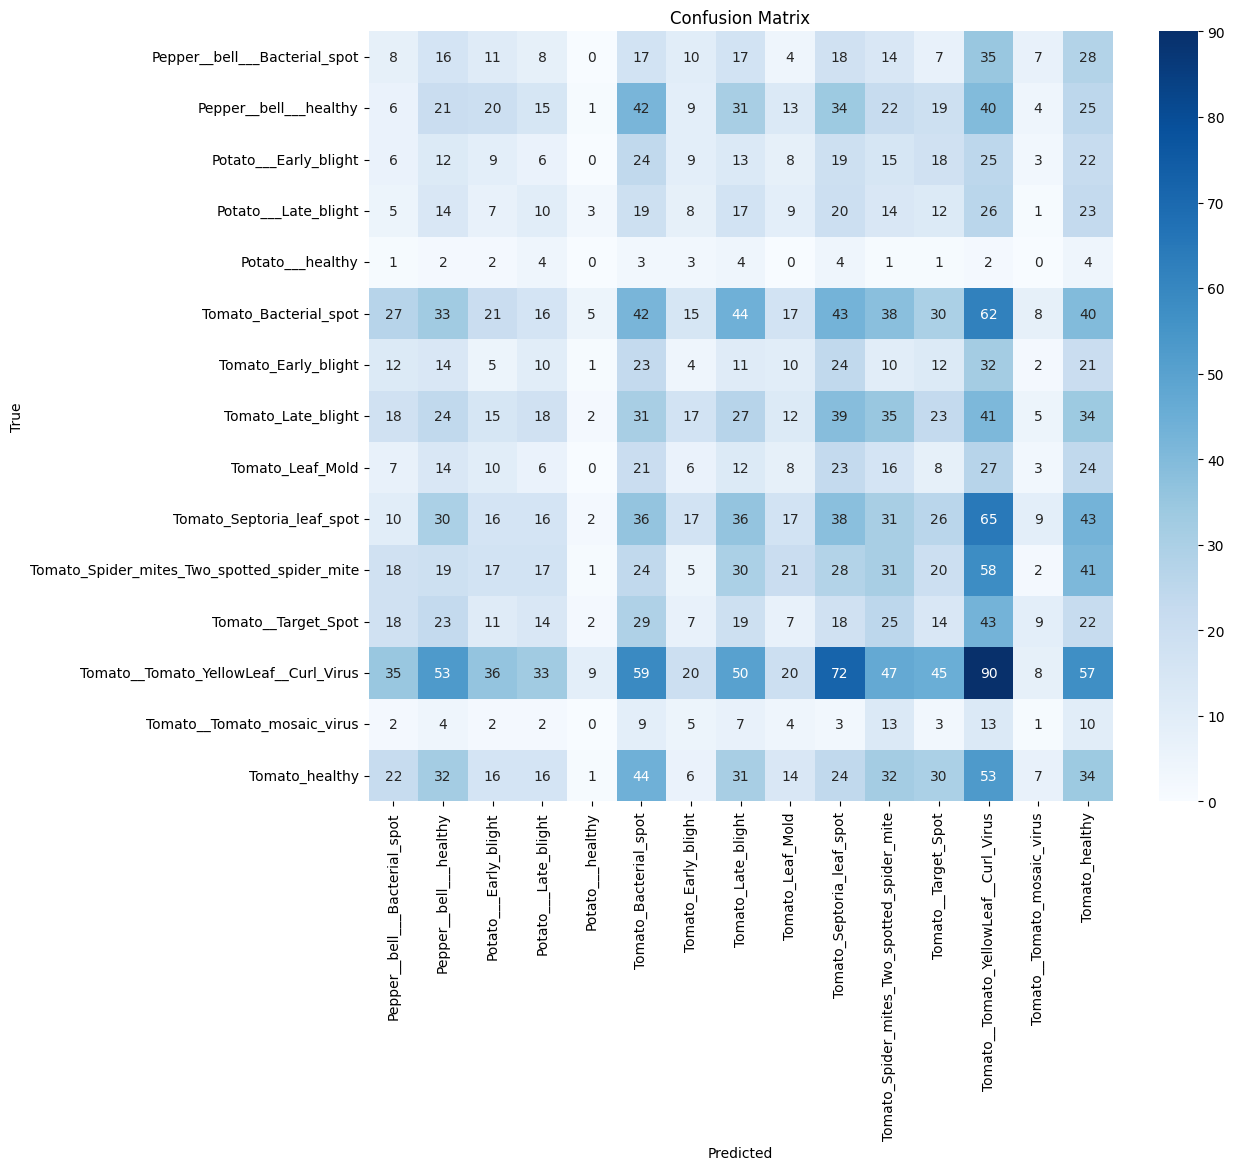

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=temp_ds.class_names,  # j'ai recuperer les noms de classe de temp.ds
    yticklabels=temp_ds.class_names,
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.show()

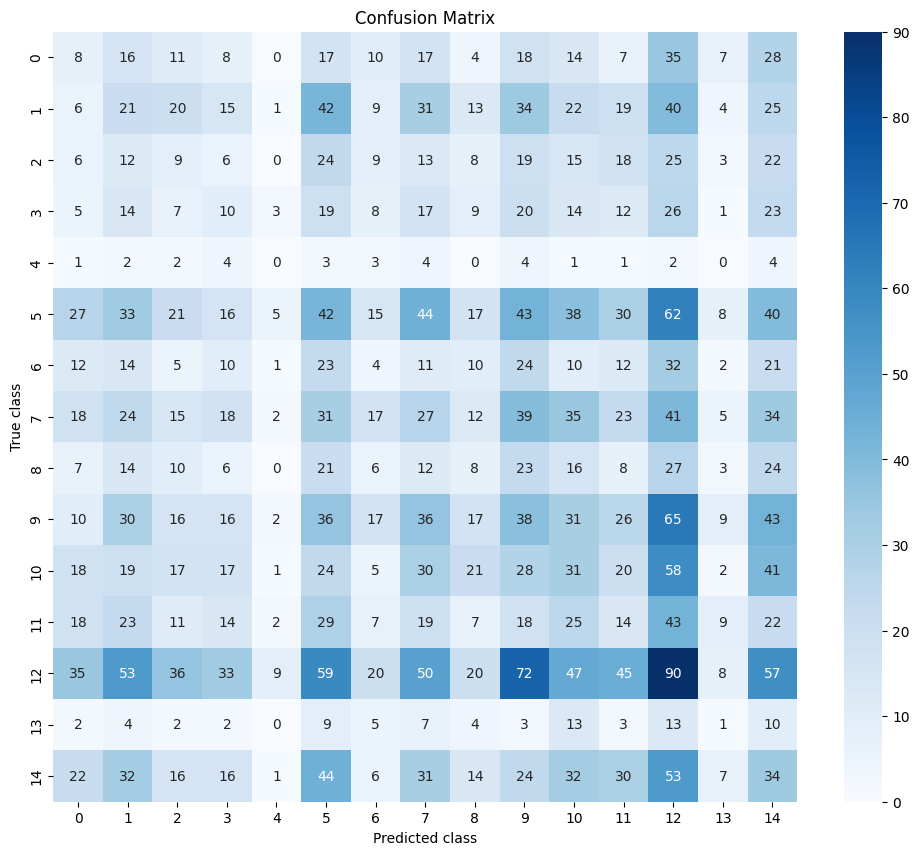

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Confusion Matrix")

plt.show()